In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import numpy.random as random

## １）	M/M/1のシミュレーション

In [2]:
#逆関数法による指数乱数の発生
def exp(x):
    y = random.random(1)
    X = -math.log(y)/x
    return(X)

In [3]:
### 到着率, サービス率を与えて平均系内人数と平均系内時間のリストを返す関数
def simulation_mm1(lam,mu):
    j = 0 #系内人数
    j_before = 0 #計算用の系内人数
    time = 0 #時間
    time_include = 0 #実際の性能評価指標の計算に用いる時間
    interval = 0 #イベントの間隔
    cum_visitor = 0 #累積系内人数
    cum_visitor_before = 0 #計算から除外する累計系内客数
    sojourn_time = list() #系内時間記録用リスト
    arrive_time = list()  #到着時刻記録用リスト
    finish_time = list()  #サービス終了時刻記録用リスト
    numerator_EL_sim = 0 #平均系内客数の計算に利用(これをtime_includeで割り算する)
    #系内人数(離散値)
    Nt_list = []
    #有効時間
    valid_time = []
    
    for state in range(1,1100):
        j_before = j
        if j==0: #系内人数が0のとき:到着しか起こらない
            j += 1
            interval = exp(lam)
            cum_visitor += 1
            arrive_time.append(time + interval)
        else:
            a = exp(lam)
            b = exp(mu)
            if a==min(a,b): #到着
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
            else: #サービス完了
                j -= 1
                interval = b
                finish_time.append(time + interval)
        if state==100:
            cum_visitor_before = cum_visitor
        if state>100:
            time_include += interval
            valid_time.append(time_include)
            numerator_EL_sim += interval*j_before
            Nt_list.append(j_before)
        time += interval

    ###性能評価指標の計算  
    #平均系内客数
    ## シミュレーション結果
    EL_sim = numerator_EL_sim/time_include
    #理論値
    EL_check = lam/(mu-lam)
    
    #平均系内時間
    for i in range(cum_visitor_before-1,len(finish_time)):
        sojourn_time.append(finish_time[i]-arrive_time[i])
    

    return EL_sim,EL_check,sojourn_time,valid_time,Nt_list

In [4]:
MM1_EL_sim, MM1_EL_check, MM1_sojourn_time, MM1_valid_time, MM1_Nt_list = simulation_mm1(3,5)

TypeError: only 0-dimensional arrays can be converted to Python scalars

## plot

In [ ]:
def MM1_Ntplot(MM1_valid_time,MM1_Nt_list):
    MM1_Nt_transition = []
    C = 0
    N =0


    #100秒まで0.001秒刻みで計測
    time_stamp = np.linspace(0,10,10001)

    for i in time_stamp:
        while (i > MM1_valid_time[C]):
            N = MM1_Nt_list[C]
            C+= 1
        
        MM1_Nt_transition.append(N)
        
    plt.plot(time_stamp,MM1_Nt_transition)
    plt.xlim(0,10)
    plt.show()


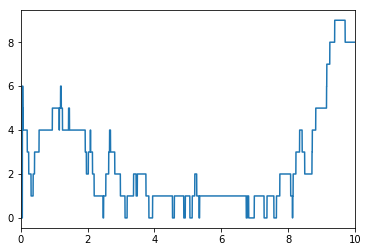

In [ ]:
MM1_Ntplot(MM1_valid_time,MM1_Nt_list)

#### 平均系内客数

In [ ]:
print("平均系内客数")
print("シミュレーション結果：",MM1_EL_sim)
print("理論値：",MM1_EL_check)

平均系内客数
シミュレーション結果： 1.157616033416595
理論値： 1.5


#### 系内客数の分布

In [ ]:
def MM1_distribution(lam,mu,MM1_valid_time, MM1_Nt_list):
    #時間間隔
    time_stamp = np.linspace(0,MM1_valid_time[len(MM1_valid_time)-1],1000000)
    counter = 0
    N = []

    for i in time_stamp:
        while (i > MM1_valid_time[counter]):
            counter += 1
        N.append(MM1_Nt_list[counter])
        
    
    dist = {}
    x = []
    y = []
    for i in N:
        if i in dist.keys():
            dist[i] += 1
        else:
            dist[i] = 1
        
    for j in sorted(dist.keys()):
        dist[j] = dist[j]/len(N)
        x.append(j)
        y.append(dist[j])
    
    ρ= (lam/mu)
    Gdist = []
    for i in x:
        Gdist.append((1-ρ)*(ρ**i)) 
    
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    ax.plot(x,y)
    ax.plot(x,Gdist)
    ax.set_xlabel("N(t)")
    ax.set_ylabel("Probability density")
    ax.legend(["simulation","theoretical"])
    plt.show()

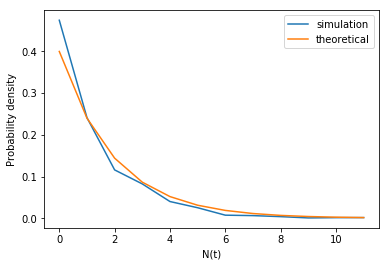

In [ ]:
MM1_distribution(3,5,MM1_valid_time, MM1_Nt_list)